In [1]:
import pandas as pd
import numpy as np
import math 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

In [3]:
df=pd.read_csv("D:\\skill improvement\\churn data\\data\\Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Business Problem

A bank is losing customers.

The objective is to predict whether a customer will leave the bank and identify the factors responsible for churn so that the bank can reduce customer loss.

In [5]:
df.shape

(10000, 14)

In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

there is no null value in any data 

In [7]:
# checking for duplicate values in the data 
df.duplicated().sum()

np.int64(0)

NO DUPLICATED VALUES IN THE DATA

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# investigate later
1. [] check does feamle are less likly in acitvemember
2. [] does geograohy female and exited have any realtion
3.

## exited

In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

<Axes: xlabel='Exited'>

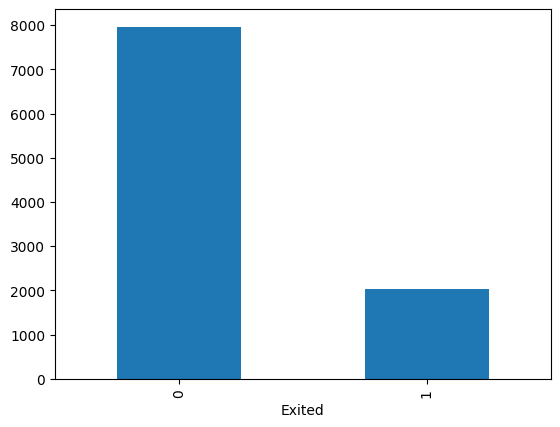

In [10]:
df["Exited"].value_counts().plot(kind='bar')

Exited:
exited have 0 as 7963 AND 1 as 2037 indicating an uneven dataset ,unbalanced data set .with majorty of the customer who havenot churned the data and vfew with the churn rate 

checking if any customer id is been reped for not



there is no elemnet with same customer id

In [11]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5692,5693,15662662,Duigan,573,France,Female,30,6,0.00,2,1,0,66190.21,0
8427,8428,15806771,Yefremova,753,France,Female,40,0,3768.69,2,1,0,177065.24,1
9185,9186,15715078,Nkemakolam,584,France,Male,35,6,161613.94,2,1,1,148238.16,0
3536,3537,15748034,Drakeford,534,France,Male,29,7,174851.90,1,1,1,79178.31,0
7254,7255,15701081,Jarvis,785,France,Male,36,2,0.00,1,0,1,61811.10,0


# CreditScore

In [12]:
# cheking for the credict score is there any perticular error or and data errror in the data 
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

<Axes: xlabel='CreditScore', ylabel='Count'>

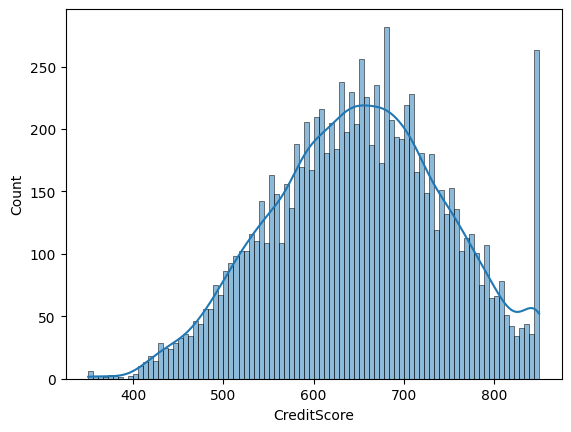

In [13]:
sns.histplot(data=df,x=df['CreditScore'],kde=True,bins=90)

In [14]:

(df['CreditScore']==850).sum()

np.int64(233)

<Axes: ylabel='CreditScore'>

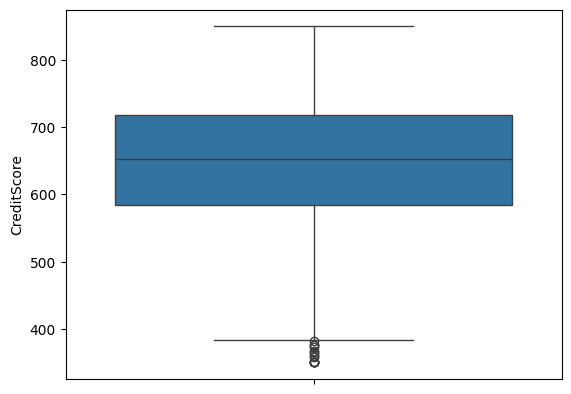

In [15]:
sns.boxplot(df['CreditScore'])

In [16]:
q1=df['CreditScore'].quantile(0.25)
q3=df['CreditScore'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
outliers = df[df['CreditScore'] < lower_bound]
print("the number of values in lower_bound= ",len(outliers))
print("cutoff = ",lower_bound)
outliers

the number of values in lower_bound=  15
cutoff =  383.0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,943,15804586,Lin,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,1194,15779947,Thomas,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,1406,15612494,Panicucci,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,1632,15685372,Azubuike,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,1839,15758813,Campbell,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,1963,15692416,Aikenhead,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,2474,15679249,Chou,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,2580,15597896,Ozoemena,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,8155,15791533,Ch'ien,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


creditscore:
1. the creditscore is btween 350 to 850 .with the mean of 650 .the 25% of the customer have creditscore less than 584. as the mean and meadian is roughtlysame it indicate  semitic dstribution of the data .as  the std is 96 it show a rought normaldistribution of the data
2. there is spik in the cutomer with the credit score 850 .is roughly 233 customer .
3. as looking at the boxplot for the creditscore it show there are some customer outside the lower whisker .indicating these could be possible outliers in the data.the data outlier all have churn rate 100 indicating a pattern between credit score and exited customers
4. we need to check wthe the credit score have any affect on the churn data .


# geography


In [17]:
#  checking the data is from which contryes 
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

<Axes: xlabel='Geography'>

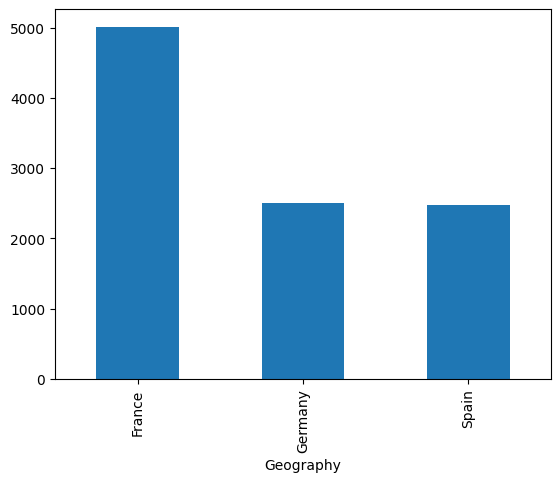

In [18]:
df['Geography'].value_counts().plot(kind='bar')

# gender

In [19]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

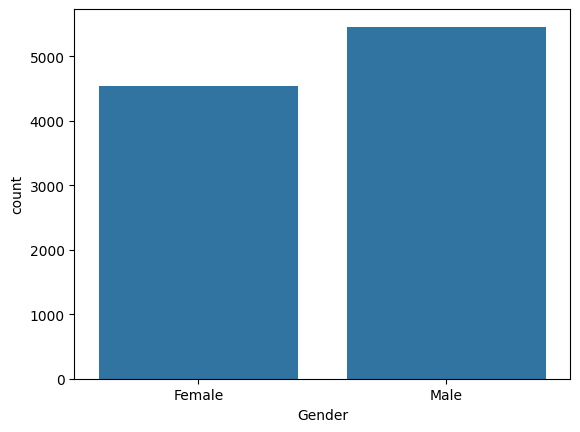

In [20]:
sns.countplot(x=df['Gender'])

1. the gender have twoo class with male and female with the male(5457) and female with (4543). this is rougly balance so we dont need any more proccess on this data
2. we need to check wther there is any relation with churn data 

# age

In [21]:
# checking for the age of the customer to classify the data into different age groups and to see if there is any outliers in the data
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

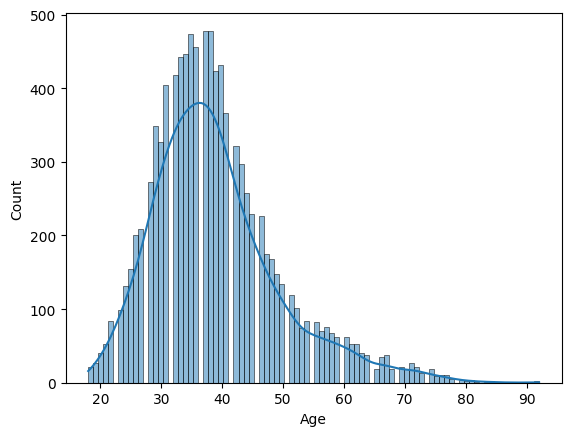

In [22]:
sns.histplot(data=df,x=df['Age'],kde=True,bins=90)

In [23]:
# does the age have any impact of the churn people or  not 
df['AgeGroup'] = pd.cut(df['Age'], 
                          bins=[18,39,64, 100], 
                          labels=['young', 'middle adulthoob',"senior"])

df['AgeGroup'].value_counts()

AgeGroup
young               5965
middle adulthoob    3731
senior               282
Name: count, dtype: int64

<Axes: xlabel='AgeGroup', ylabel='count'>

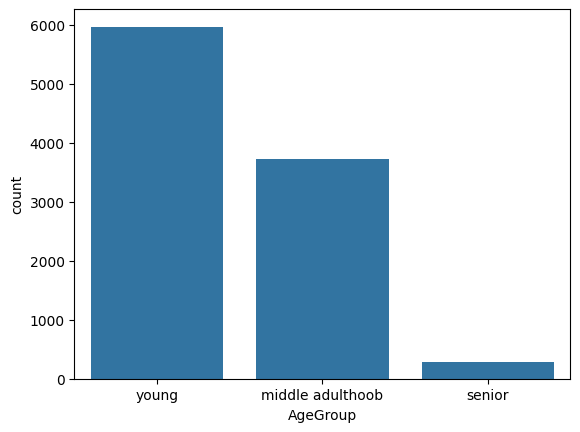

In [24]:
sns.countplot(data=df, x='AgeGroup')


1. the age group have a range of 18 to 92 were std 10 and the mean is 38 were as meadian is 37 indicating a roughly  normal distribution of the data 
2. have divide the age column into 3 class were the young(18-39),adult(40-65),and senior is 66+
3. to check the type of customer who use are product
4. there are more young customer with 5065 in the data follwed up by adult qith 3731 and 282 senior customer 
5. we have to check the relation btween the age and exited customer .to see if any specific class is to churn more 
 

In [25]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
1857,1858,15709338,T'ao,544,France,Female,29,1,118560.55,1,1,1,164137.36,0,young
8888,8889,15637788,Schmidt,743,France,Male,23,3,110203.77,1,1,0,95583.45,0,young
8252,8253,15734737,Bruno,744,France,Male,56,9,0.00,2,1,1,169498.61,0,middle adulthoob
7323,7324,15750476,Hendrick,742,Spain,Male,24,8,0.00,2,1,0,4070.28,0,young


# tenure


In [26]:
# tenure :what is the max and minum year a customer have been with us
df['Tenure'].describe()

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64

In [27]:
df['Tenure'].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

<Axes: xlabel='Tenure'>

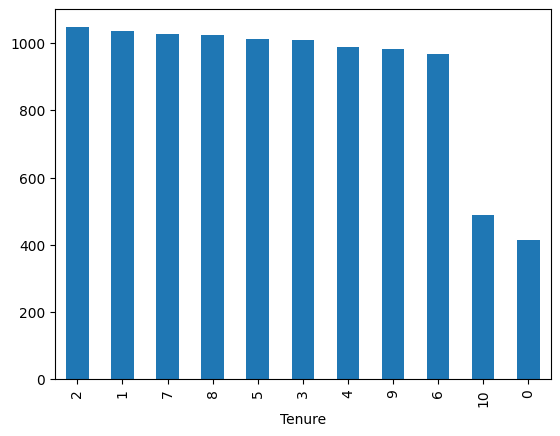

In [28]:
df['Tenure'].value_counts().plot(kind='bar')

# observation:
0. the tenure is range between 0 to 10.with most of the customer with 1 to 2 and else rest there are  few customer who have zero tenure and 10 year.
1. we can break the group into bins with new,middle ans loyal customer to check relation of them with churn data.


# balance

In [29]:
df['Balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

<Axes: xlabel='Balance', ylabel='Count'>

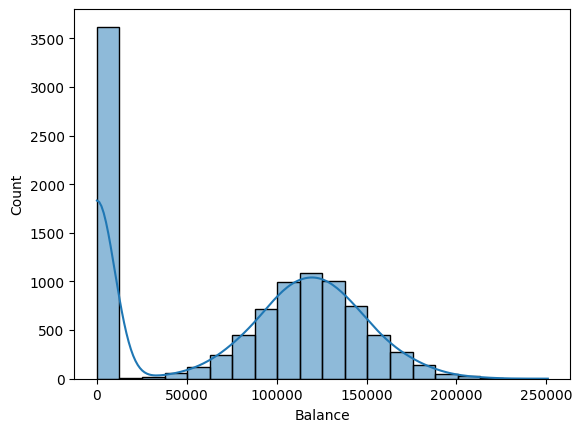

In [30]:
sns.histplot(df['Balance'],kde=True,bins=20)

In [31]:
#  checking the numebr of customer with 0 balance
(df['Balance']==0).sum()

np.int64(3617)

<Axes: ylabel='Balance'>

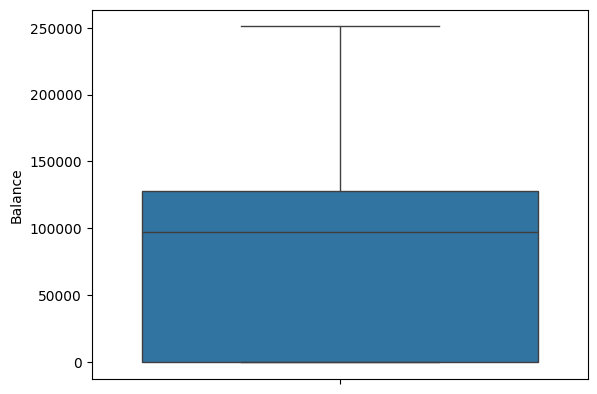

In [32]:
sns.boxplot(df['Balance'])

In [33]:
# cheking the iqr range of the data :
q1=df['Balance'].quantile(0.25)
q3=df['Balance'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=df[df['Balance']<lower_bound]
print(f"the lower round range is {lower_bound} and upper bound is {upper_bound}")
print(f"number of outliers are {len(outliers)}")

the lower round range is -191466.36000000002 and upper bound is 319110.60000000003
number of outliers are 0


observation :
1. customer balance ranges from 0 to 250k ,with a mean of 70k and the std to be 62397and the median of 97198 .the alignment betwween the mean and meadian is not same indicating the rought asymetric distributuion of the data.
2. the 25% of the customer have 0 balnce and the rest have from 97198 to250k. indicating a hidden patern btween these too.we need to check what are the customer with zero balznce are they new customer or any other possible cause.
3. this pattern arrise a question wther the customer with zero balnce have diifrent churn rate then the active customer with balnce 

In [34]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
266,267,15653857,Wallis,498,France,Male,34,2,0.00,2,1,1,148528.24,0,young
5805,5806,15814236,Kay,537,Spain,Female,38,1,96939.06,1,1,1,102606.92,0,young
2810,2811,15595388,Yeh,594,France,Female,30,10,0.00,2,1,1,124071.71,0,young
164,165,15658929,Taverner,683,Spain,Male,29,0,133702.89,1,1,0,55582.54,1,young


# number of product

In [35]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

<Axes: xlabel='NumOfProducts', ylabel='count'>

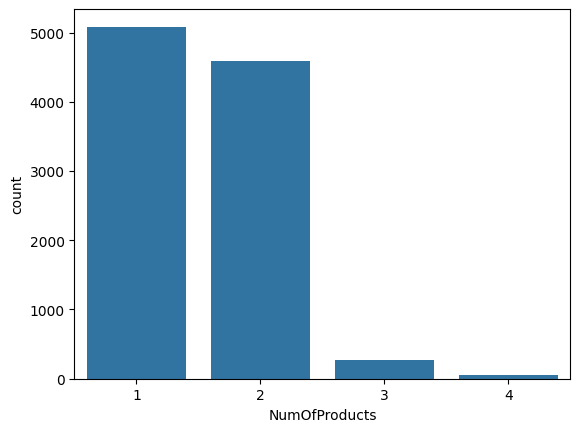

In [36]:
sns.countplot(x=df['NumOfProducts'])

numofproduct:
1. the range of the product varies from 1 to 4 with the most customer with 1 product and least with 4 products
2. the numofprocut can be a cause for the  churn customer .



In [37]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
2558,2559,15727021,Obialo,727,Germany,Female,30,8,119027.28,2,1,1,137903.54,0,young
5299,5300,15792989,Bianchi,543,France,Female,71,1,104308.77,1,1,1,25650.04,0,senior
3508,3509,15614230,T'an,426,France,Female,34,3,0.00,2,1,1,61230.83,0,young
1625,1626,15630321,Hu,680,France,Male,44,3,0.00,2,1,0,86935.08,0,middle adulthoob


# has credit card

In [38]:
# has credict card
df['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

<Axes: xlabel='HasCrCard', ylabel='count'>

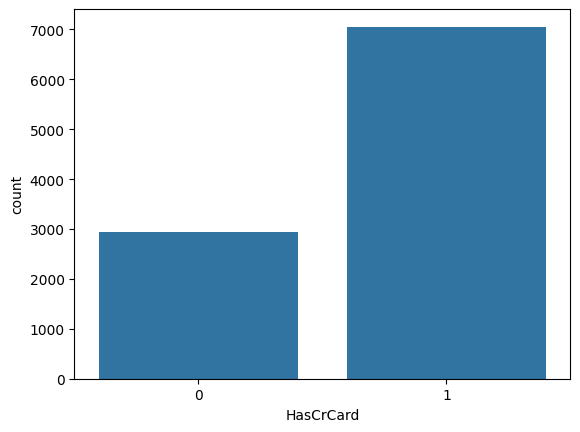

In [39]:
sns.countplot(x=df['HasCrCard'])

hascrcard
1. umbalnaced dataset with no crcard customers

In [40]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
9975,9976,15666295,Smith,610,Germany,Male,50,1,113957.01,2,1,0,196526.55,1,middle adulthoob
13,14,15691483,Chin,549,France,Female,25,5,0.00,2,0,0,190857.79,0,young
8869,8870,15733597,Y?an,669,France,Female,41,0,150219.41,2,0,0,107839.03,0,middle adulthoob
4963,4964,15652084,Boni,515,France,Male,40,0,109542.29,1,1,1,166370.81,0,middle adulthoob


# isactivemember

In [41]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

<Axes: xlabel='IsActiveMember'>

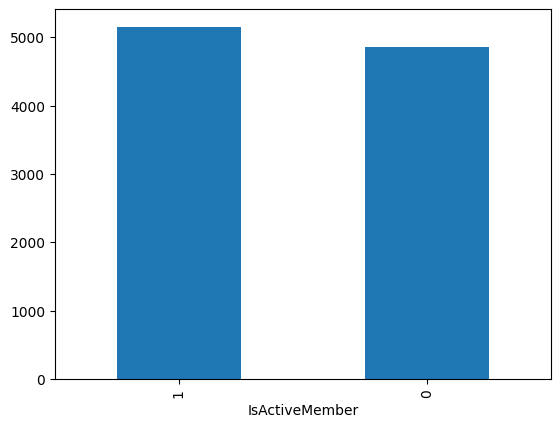

In [42]:
df['IsActiveMember'].value_counts().plot(kind='bar')

# estimated sallary

In [43]:
# estimate salary
df['EstimatedSalary'].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [44]:
df['EstimatedSalary'].shape

(10000,)

In [45]:
df['EstimatedSalary'].nunique()

9999

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

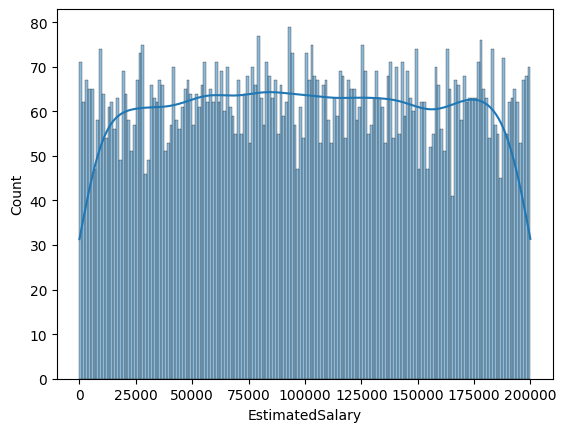

In [46]:
sns.histplot(df['EstimatedSalary'],kde=True,bins=160)

observation:
The EstimatedSalary feature appears to follow an approximately uniform distribution across its range (0–200,000). There are no significant peaks, skewness, or clusters, indicating that customers are evenly distributed across different salary levels. This suggests that the dataset was likely generated or sampled to cover the full salary range rather than reflecting a naturally occurring salary distribution.

Estimatedsalary
1. estimate salary ranges from 11 to 1999992 , the mean is 100090 and the meadian is about the same with 100193 .indicating a roughly simeritric data formation 
there are 25% of the people with salary about 50k 
the min salry of the persom is 11.58 could be a point to discuss 

In [47]:
df[df['EstimatedSalary']<100]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
2362,2363,15791053,Lucciano,709,Germany,Male,45,4,122917.71,1,1,1,11.58,1,middle adulthoob
5548,5549,15639662,Phillips,710,France,Male,38,2,0.00,2,1,0,96.27,0,young
9010,9011,15786463,Hsing,645,Germany,Female,59,8,121669.93,2,0,0,91.75,1,middle adulthoob
9647,9648,15679693,Walker,625,France,Male,31,5,0.00,2,0,1,90.07,0,young


# Bivarent eda

In [48]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
2715,2716,15682547,Lucchese,649,France,Male,38,1,122214.00,1,0,1,88965.46,0,young
6817,6818,15593128,Vinogradoff,608,France,Female,56,10,129255.20,2,1,0,142492.04,1,middle adulthoob
7414,7415,15802869,Ball,737,Germany,Female,45,2,99169.67,2,1,1,78650.95,0,middle adulthoob
58,59,15623944,T'ien,511,Spain,Female,66,4,0.00,1,1,0,1643.11,1,senior


# credit score vs exited


In [49]:
# lets create a new feature with 3 class for credit score[poor,good,excellent]
df['credit_score_class'] = pd.cut(df['CreditScore'],
                                  bins=[300,549,649,749,900],
                                  labels=['Poor','fair','good','excellent'])
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
1751,1752,15632256,Schroeder,541,France,Male,29,7,127504.57,1,0,0,86173.92,0,young,Poor
3570,3571,15706005,Roberts,674,France,Male,46,2,174701.05,1,1,0,90189.72,1,middle adulthoob,good
5483,5484,15666032,Mancini,568,Spain,Male,28,1,127289.28,1,0,0,45611.51,0,young,fair
4201,4202,15621227,Hs?eh,668,Germany,Female,46,7,161806.09,1,1,1,173052.19,0,middle adulthoob,good


In [50]:
df['credit_score_class'].value_counts()

credit_score_class
good         3477
fair         3310
excellent    1623
Poor         1590
Name: count, dtype: int64

In [51]:
# now as we have divided the creditscore column into other sub class we need to check the relation between the churn rate and the credit score class
df.groupby(df['credit_score_class'])['Exited'].mean()*100 


C:\Users\karan\AppData\Local\Temp\ipykernel_18936\3562721763.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df['credit_score_class'])['Exited'].mean()*100


credit_score_class
Poor         22.704403
fair         20.785498
good         19.183204
excellent    19.778189
Name: Exited, dtype: float64

In [52]:
# now as we have divided the creditscore column into other sub class we need to check the relation between the churn rate and the credit score class
df.groupby(df['credit_score_class'])['Exited'].value_counts()


C:\Users\karan\AppData\Local\Temp\ipykernel_18936\2037143163.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df['credit_score_class'])['Exited'].value_counts()


credit_score_class  Exited
Poor                0         1229
                    1          361
fair                0         2622
                    1          688
good                0         2810
                    1          667
excellent           0         1302
                    1          321
Name: count, dtype: int64

observation :
1. i have divided the credict score into 4 sub class poor,fair,good,execlent to see what size group have impact on the churn rate
2. the poor[1590][22] fair[3310][20]good [1602][19]excelent[1523][19] were as the churn rate .as there is not much of the change in the data/churn rate it indicated as poor reltaion with the churn data .
3. we need to check wther the credit score have any sort of relation with any other kind
 

In [53]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
8786,8787,15770968,Leason,741,Germany,Female,19,8,108711.57,2,1,0,24857.25,0,young,good
3887,3888,15769110,Stehle,653,France,Female,46,5,0.00,2,1,0,49707.85,0,middle adulthoob,good
1812,1813,15595221,Trevisano,850,Germany,Female,33,7,134678.13,1,1,0,113177.95,0,young,excellent
7776,7777,15685243,Jamieson,736,France,Female,63,10,0.00,2,0,1,502.70,0,middle adulthoob,good


# geography vs exited

In [54]:
# checking if churn rate have anything to do with geography area
(df.groupby(df['Geography'])['Exited'].mean()*100).sort_values(ascending=False)


Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64

In [55]:
df.groupby(df['Geography'])['Exited'].value_counts()

Geography  Exited
France     0         4204
           1          810
Germany    0         1695
           1          814
Spain      0         2064
           1          413
Name: count, dtype: int64


1. the geography contains 3 value,france,germany,spain,. the france is the counry with most custoomers from follwed up by germany and then spain.
the churn rate percentage of the france is 16 .and the germany is 32 percent.half of the customer of germony have churned .indicating a sepcific relation between geography and churn customer. why does germany customer churn so much could be a point to research .

In [56]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
8578,8579,15707011,Morrison,495,France,Male,47,10,137682.68,1,1,0,71071.47,0,middle adulthoob,Poor
676,677,15607040,P'an,593,Spain,Female,38,4,88736.44,2,1,0,67020.03,0,young,fair
8529,8530,15623858,Charteris,603,France,Male,45,9,0.00,1,0,0,148516.79,0,middle adulthoob,fair
3381,3382,15629511,Lavrentiev,738,France,Male,49,6,106770.82,1,1,0,123499.27,0,middle adulthoob,good


# gender vs exited

In [57]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [58]:
df.groupby(df['Gender'])['Exited'].mean()*100


Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

In [59]:
df.groupby(df['Gender'])['Exited'].value_counts()


Gender  Exited
Female  0         3404
        1         1139
Male    0         4559
        1          898
Name: count, dtype: int64

observation:
1. the gender[m,f] column have some relation with the churn rate as there are more female(25%) to churn rather than the male(16) .indicating some sort of relation with the churn rate . we futher need to check wther there is any realtion with any other column which can cause this problem.
2. lets check wther the quantaty of female have any sepecific location(geography) 

# gender vs geography

In [60]:
df.groupby(df['Geography'])['Gender'].value_counts()

Geography  Gender
France     Male      2753
           Female    2261
Germany    Male      1316
           Female    1193
Spain      Male      1388
           Female    1089
Name: count, dtype: int64

observation:
1. there is not any kind of specific info avalabel for the gender and geography columns . indicating a very few relation btween these twoo

# gender vs isactivemember


In [61]:
df.groupby(['Gender'])['IsActiveMember'].value_counts()

Gender  IsActiveMember
Female  1                 2284
        0                 2259
Male    1                 2867
        0                 2590
Name: count, dtype: int64

observation:
1. there realtion bewttern gender and isactivemember is rougly same .same number of acitve nad inactive member present .assuming a very low reltino btweeen these too but we can check the relation with exitced to see any other diffrence 

In [62]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
2212,2213,15770974,Nwabugwu,741,Germany,Female,37,8,170840.08,2,0,0,109843.16,0,young,good
6576,6577,15808905,Levan,823,France,Male,37,5,164858.18,1,1,1,173516.71,0,young,excellent
3705,3706,15769645,Senior,612,France,Female,35,3,0.00,1,1,1,48108.72,0,young,fair
8650,8651,15731865,Unwin,637,France,Male,27,1,0.00,2,1,0,91291.20,0,young,fair


# gendre vs agegroup

In [63]:
df.groupby(["Gender"])["AgeGroup"].value_counts()

Gender  AgeGroup        
Female  young               2630
        middle adulthoob    1781
        senior               128
Male    young               3335
        middle adulthoob    1950
        senior               154
Name: count, dtype: int64

observation:
1. there is not specific relation or point to note inthe gender vs agegroup.indcatinf a samll reltion btween them 

# agegroup vs exited 

In [64]:
(df.groupby(df['AgeGroup'])['Exited'].mean()*100).sort_values(ascending=False)



C:\Users\karan\AppData\Local\Temp\ipykernel_18936\23430265.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(df['AgeGroup'])['Exited'].mean()*100).sort_values(ascending=False)


AgeGroup
middle adulthoob    37.443045
senior              15.248227
young                9.974853
Name: Exited, dtype: float64

In [65]:
df.groupby(df['AgeGroup'])['Exited'].value_counts()

C:\Users\karan\AppData\Local\Temp\ipykernel_18936\795153283.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df['AgeGroup'])['Exited'].value_counts()


AgeGroup          Exited
young             0         5370
                  1          595
middle adulthoob  0         2334
                  1         1397
senior            0          239
                  1           43
Name: count, dtype: int64

observation:
1. i have divide the age chart into 3 part[young,adult,senior].there for the we have young customer with the customer 595 churned (out of 5965 ) and adult churned with 1397(out of 3717 ) making 37 % churn rate and we have very few senior customer with churn rate of 15 % (total count us 282 ).
2. there are very few customer who have churned from young age . wereas the customer who adut have a very huge churn rate.the customer churned form adult is roughly double the size of young people.rather the adultis having roughly half of the cusotmer in the age group.this could cause us a risk.but it is yet to serch why is this churning so much
3. we need to futher see why are the adut group churning so much .is it beacuse of the geography or any kind of product or balnce issue .we need to run a reserch on these
4. The senior group is small (n=282) with a 15.2% churn rate — lower than middle adulthood but based on a much smaller sample than the other two groups, so this rate should be treated as less statistically reliable and not over-interpreted as a strong "seniors are loyal" finding.

In [66]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
6878,6879,15636592,Iroawuchi,651,France,Male,35,0,181821.96,2,0,1,36923.67,1,young,good
1191,1192,15686909,Lung,639,Germany,Male,27,3,150795.81,1,0,1,85208.93,0,young,fair
405,406,15692761,Pratt,718,France,Male,36,9,0.00,1,1,0,45909.87,0,young,good
9428,9429,15752984,Chifley,737,France,Female,70,9,87542.89,2,1,1,42576.86,0,senior,good


# tenure vs exited

In [67]:
(df.groupby(['Tenure'])['Exited'].mean()*100).sort_values(ascending=False)

Tenure
0     23.002421
1     22.415459
9     21.646341
3     21.110010
5     20.652174
10    20.612245
4     20.525784
6     20.268873
8     19.219512
2     19.179389
7     17.217899
Name: Exited, dtype: float64

In [68]:
(df.groupby(['Tenure'])['Exited'].value_counts())

Tenure  Exited
0       0         318
        1          95
1       0         803
        1         232
2       0         847
        1         201
3       0         796
        1         213
4       0         786
        1         203
5       0         803
        1         209
6       0         771
        1         196
7       0         851
        1         177
8       0         828
        1         197
9       0         771
        1         213
10      0         389
        1         101
Name: count, dtype: int64

observation:
the tenure and exited does seem to have that much effect on the churn rate there is very slighlty dependence of the tenure over the exited group.
we can group the tenure into some sub classed to see if they show some relation with the churn /exited label.


In [69]:
#  we are going to divide the tenure column into three sub classed with [new,average, loyal ] customer to check of there is any chang in the relation ship
df['tenure_class']=pd.cut(df['Tenure'],
                          bins=[-1,2,5,10],
                          labels=['new','mid','loyal'])

In [70]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
7999,8000,15591489,Davison,826,France,Male,26,5,142662.68,1,0,0,60285.30,0,young,excellent,mid
1173,1174,15808182,Beneventi,478,Spain,Female,36,3,92363.30,2,1,0,44912.70,0,young,Poor,mid
7094,7095,15655464,Combes,640,France,Female,67,3,0.00,1,0,1,42964.63,0,senior,fair,mid
622,623,15636444,Craig,535,Germany,Female,53,5,141616.55,2,1,1,75888.65,0,middle adulthoob,Poor,mid


# tenure_class vs exited

In [71]:
df.groupby(['tenure_class'])['Exited'].mean()*100

C:\Users\karan\AppData\Local\Temp\ipykernel_18936\1947653593.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_class'])['Exited'].mean()*100


tenure_class
new      21.153846
mid      20.764120
loyal    19.670672
Name: Exited, dtype: float64

In [72]:
df.groupby(['tenure_class'])['Exited'].value_counts()

C:\Users\karan\AppData\Local\Temp\ipykernel_18936\3693644910.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_class'])['Exited'].value_counts()


tenure_class  Exited
new           0         1968
              1          528
mid           0         2385
              1          625
loyal         0         3610
              1          884
Name: count, dtype: int64

observation:
1. the new[21%] were mid[20] and loyal[19] churn rate .
2. the bivarent eda of tenure_class and exited doesnt show much of the relation. there is slighty diffrence when we gow from new to loyal customer the churn rate decrese .


In [73]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
7095,7096,15783883,Onwuka,753,Germany,Female,38,1,117314.92,1,1,0,122021.33,1,young,excellent,new
9021,9022,15712199,Ijendu,655,Germany,Female,61,2,183997.70,2,1,1,161217.18,0,middle adulthoob,good,new
3367,3368,15648881,Tsai,581,Germany,Male,40,0,101016.53,1,0,1,7926.35,1,middle adulthoob,fair,new
7689,7690,15777452,Sauve,587,France,Female,46,6,88820.29,1,0,0,70224.34,0,middle adulthoob,fair,loyal


In [74]:
df['tenure_class'].value_counts()

tenure_class
loyal    4494
mid      3010
new      2496
Name: count, dtype: int64

# balance vs exited 

In [75]:
#  checking if the customer with zero balance have high churn rate than the balnce customer 
zero_balnce=(df['Balance']==0).mean()*100 # checking for the percentage of people with zero balace
print(f"% of the customer have zero balnce = {round(zero_balnce)} %")
# checking if the balnce zero ahve relation with churn cutomer,
print(df.groupby(df["Balance"] == 0)["Exited"].mean() * 100)


% of the customer have zero balnce = 36 %
Balance
False    24.079586
True     13.823611
Name: Exited, dtype: float64


observation :
1. zero vs balance 
Contrary to the assumption that zero-balance customers are more likely to be disengaged and churn, the data shows the opposite: customers with a non-zero balance churn at 24.1%, nearly double the 13.8% churn rate of zero-balance customers (who make up 36% of the customer base). This suggests zero-balance customers may primarily hold non-deposit products (e.g., credit cards or loans) where balance isn't a meaningful engagement signal, while customers with real balances may be more likely to actively compare and switch to competitor offers. This reframes Balance from a simple "more balance = more engaged" assumption into a feature that likely interacts with NumOfProducts and needs closer segmentation rather than being treated as a standalone predictor.

# balance vs noof product

In [110]:
# lets check whether the customer with zero balance have any relation with the number of product they have or not.
df[df['Balance']==0].groupby(df['NumOfProducts'])['Exited'].value_counts()

NumOfProducts  Exited
1              0          567
               1          338
2              0         2514
               1           86
3              1           62
               0           36
4              1           14
Name: count, dtype: int64

In [113]:

zero_bal=df[df['Balance']==0]
print(f"nomber of customer with zero balance = {len(zero_bal)}")
zero_bal['NumOfProducts'].value_counts()    

nomber of customer with zero balance = 3617


NumOfProducts
2    2600
1     905
3      98
4      14
Name: count, dtype: int64

In [115]:
zero_bal['HasCrCard'].value_counts()

HasCrCard
1    2592
0    1025
Name: count, dtype: int64

In [116]:
zero_bal.groupby(zero_bal['HasCrCard'])['Exited'].value_counts()

HasCrCard  Exited
0          0          877
           1          148
1          0         2240
           1          352
Name: count, dtype: int64

In [117]:
# Baseline: % of all customers with a credit card
overall_card_rate = df['HasCrCard'].mean() * 100

# % of zero-balance customers with a credit card
zero_balance_card_rate = df[df['Balance']==0]['HasCrCard'].mean() * 100

# % of non-zero balance customers with a credit card
nonzero_balance_card_rate = df[df['Balance']!=0]['HasCrCard'].mean() * 100

print(f"Overall: {overall_card_rate:.1f}%")
print(f"Zero balance: {zero_balance_card_rate:.1f}%")
print(f"Non-zero balance: {nonzero_balance_card_rate:.1f}%")

Overall: 70.5%
Zero balance: 71.7%
Non-zero balance: 69.9%


In [120]:
# NumOfProducts distribution among zero-balance customers
df[df['Balance']==0]['NumOfProducts'].value_counts(normalize=True) * 100



NumOfProducts
2    71.882776
1    25.020735
3     2.709428
4     0.387061
Name: proportion, dtype: float64

In [119]:
# NumOfProducts distribution among non-zero balance customers  
df[df['Balance']!=0]['NumOfProducts'].value_counts(normalize=True) * 100

NumOfProducts
1    65.470782
2    31.176563
3     2.631991
4     0.720664
Name: proportion, dtype: float64

Balance vs NumOfProducts (testing the "why" behind Balance's churn pattern)
Zero-balance customers are heavily concentrated in the 2-product tier (71.9%, vs. 31.2% among non-zero-balance customers), while non-zero-balance customers are mostly 1-product holders (65.5%, vs. 25.0% for zero-balance). Since 2-product customers churn at the lowest rate overall (7.6%) and 1-product customers churn much higher (27.7%), this explains the Balance-churn pattern cleanly: zero-balance customers churn less (13.8%) largely because they overlap heavily with the low-risk 2-product segment, not because a zero balance itself is protective. This suggests Balance and NumOfProducts are capturing overlapping signal rather than two independent effects — worth keeping in mind for feature engineering, since including both as separate model inputs may add redundancy rather than new information.

In [76]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
8171,8172,15588859,Rowley,496,Spain,Female,44,0,179356.28,2,1,0,2919.21,1,middle adulthoob,Poor,new
5449,5450,15592028,Roberts,549,France,Female,46,7,0.00,1,1,1,109057.56,0,middle adulthoob,Poor,loyal
6464,6465,15591512,Whittaker,564,Germany,Female,33,2,115761.51,1,0,1,112350.21,1,young,fair,new
5549,5550,15567013,De Luca,779,Spain,Male,33,3,0.00,2,1,0,30804.68,0,young,excellent,mid


# number of product vs exited

In [77]:
df.groupby(df['NumOfProducts'])['Exited'].mean()*100



NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

In [78]:
df.groupby(df['NumOfProducts'])['Exited'].value_counts()

NumOfProducts  Exited
1              0         3675
               1         1409
2              0         4242
               1          348
3              1          220
               0           46
4              1           60
Name: count, dtype: int64

noofproduct vs exited
1. the most number of people have churned form the 1 with the count of 1409
2. there are very few customer who have churend from 2 .indicating customer with 2 product are more likely loyal to the bank
3. there is huge churn rate btween 3 and 4 almost all of the customer have churned from the bank.indicating some issue with this

In [79]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
7306,7307,15807546,Chinwendu,837,France,Female,38,2,0.00,2,1,1,46395.21,0,young,excellent,new
7711,7712,15763029,Ch'iu,612,Germany,Male,46,9,161450.03,1,1,1,96961.00,1,middle adulthoob,fair,loyal
553,554,15709324,Bruce,417,France,Male,34,7,0.00,2,1,0,55003.79,0,young,Poor,loyal
5185,5186,15801169,Yegorova,764,Germany,Female,39,9,138341.51,1,1,0,50072.94,1,young,excellent,loyal


# hascrcard vs exited

In [80]:
df.groupby(df['HasCrCard'])['Exited'].mean()*100

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

In [81]:
df.groupby(df['HasCrCard'])['Exited'].value_counts()

HasCrCard  Exited
0          0         2332
           1          613
1          0         5631
           1         1424
Name: count, dtype: int64

observation:
1. person with the credict card and with not the credit card have almost same churn persentage but the numberof customer using credict card is almost 2 time of not using one 
2. indicating the person with the credict card have slight;y hight chance to leave the bank . what cause them to leave .indicatong some issue int he credict card 

In [82]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
1360,1361,15694409,Tsao,647,Germany,Female,22,3,97975.82,2,0,1,62083.00,0,young,fair,mid
361,362,15696674,Robinson,643,Germany,Female,45,2,150842.93,1,0,1,2319.96,1,middle adulthoob,fair,new
9105,9106,15685476,Tseng,658,France,Male,31,5,100082.14,1,0,1,49809.88,0,young,good,mid
4577,4578,15703979,Evans,580,Germany,Male,39,3,119688.81,1,1,0,137041.26,0,young,fair,mid


# IsActiveMember vs exited 

In [83]:
df.groupby(df['IsActiveMember'])['Exited'].mean()*100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

In [84]:
df.groupby(df['IsActiveMember'])['Exited'].value_counts()

IsActiveMember  Exited
0               0         3547
                1         1302
1               0         4416
                1          735
Name: count, dtype: int64

observation:
inactivemember shows 26.9% churn rate(1302 for 3547) vs active member shows the 14.3% of churn rate . sinse the two group are same in size  the pattern is geniun sign for the churn data .this state that activity level is also the cause for the churn .inactive member are more likely to leve
likely because of the low attention,engagement or any other think. isactivemember could be a strong point/feature is for the churn data. we can combine the data with other feautre to make it more important

# geopraphy vs isactivemember


In [85]:
# lets check how many customer isactive member are from which regein of  earth 
df.groupby(df['Geography'])['IsActiveMember'].value_counts()

Geography  IsActiveMember
France     1                 2591
           0                 2423
Germany    0                 1261
           1                 1248
Spain      1                 1312
           0                 1165
Name: count, dtype: int64

observation:
1. there amount of customer for every geography is almost the same.

# isactivemember and number of product

In [86]:
df.groupby(df['NumOfProducts'])['IsActiveMember'].value_counts()

NumOfProducts  IsActiveMember
1              1                 2563
               0                 2521
2              1                 2446
               0                 2144
3              0                  153
               1                  113
4              0                   31
               1                   29
Name: count, dtype: int64

observation:
1. there are roughly same amount of customer for all the noofproducts 

In [87]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
6779,6780,15587066,Kovaleva,535,France,Male,38,2,119272.29,1,0,0,195896.59,1,young,Poor,new
5678,5679,15732265,Obialo,630,France,Male,33,9,0.00,2,1,0,64804.59,0,young,fair,loyal
6998,6999,15640074,Barrett,666,Spain,Female,47,5,0.00,1,0,0,166650.90,1,middle adulthoob,good,mid
3321,3322,15681327,Akhtar,682,France,Male,30,9,0.00,2,1,1,2053.42,0,young,good,loyal


In [88]:
# lets check if there is any linrear relation between the estimated salary and balance of the customer

<Axes: xlabel='EstimatedSalary', ylabel='Balance'>

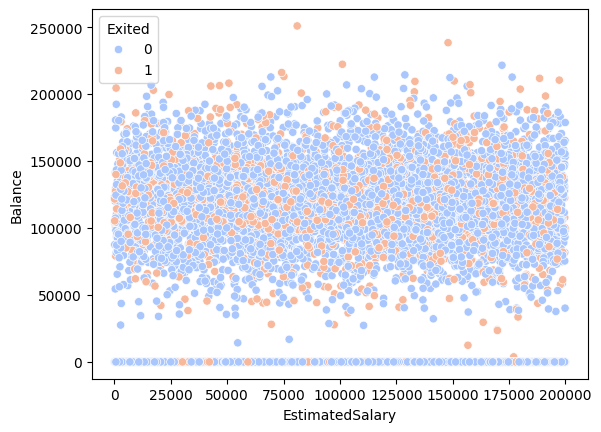

In [89]:
sns.scatterplot(data=df,x=df['EstimatedSalary'],y=df['Balance'],hue=df['Exited'],palette='coolwarm')

# multivarent eda 

In [90]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
99,100,15633059,Fanucci,413,France,Male,34,9,0.00,2,0,0,6534.18,0,young,Poor,loyal
164,165,15658929,Taverner,683,Spain,Male,29,0,133702.89,1,1,0,55582.54,1,young,good,new
5378,5379,15720968,Young,606,Germany,Male,27,2,130274.26,2,1,0,147533.09,0,young,fair,new
9786,9787,15609521,Chimaraoke,803,Germany,Male,34,4,142929.16,2,1,1,114869.56,0,young,excellent,mid


In [91]:
# credit score num of product and exited 
df.groupby(['credit_score_class','NumOfProducts'])['Exited'].mean().unstack()*100

C:\Users\karan\AppData\Local\Temp\ipykernel_18936\3453481822.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['credit_score_class','NumOfProducts'])['Exited'].mean().unstack()*100


NumOfProducts,1,2,3,4
credit_score_class,,,,
Poor,29.988053,8.948864,95.238095,100.0
fair,28.083832,7.989522,81.609195,100.0
good,25.775522,7.353865,79.166667,100.0
excellent,28.855721,5.989583,80.487805,100.0


In [92]:
# checking if the custome with only one product are also holding credit card onto them
df[df['NumOfProducts'] == 1]['HasCrCard'].value_counts()

HasCrCard
1    3578
0    1506
Name: count, dtype: int64

In [93]:
# Filter for customers with 1 product, then group by HasCrCard, calculate mean of Exited, and unstack
new_df=df[df['NumOfProducts'] == 1]
new_df.groupby(new_df['HasCrCard'])['Exited'].mean()* 100   

HasCrCard
0    27.755644
1    27.697037
Name: Exited, dtype: float64

observation :
1. the customer with any credit score but with 2 product are less likely to churn . but customer with more than 3 or customer with 1 product are more leikely to churn from the bank

In [94]:
df.groupby(['tenure_class', 'NumOfProducts']).size()

C:\Users\karan\AppData\Local\Temp\ipykernel_18936\544717546.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_class', 'NumOfProducts']).size()


tenure_class  NumOfProducts
new           1                1277
              2                1145
              3                  59
              4                  15
mid           1                1534
              2                1360
              3                  98
              4                  18
loyal         1                2273
              2                2085
              3                 109
              4                  27
dtype: int64

In [95]:
df[(df['tenure_class']=='new') & (df['NumOfProducts']>=3)]['Exited'].mean() * 100

np.float64(85.13513513513513)

In [96]:
df[(df['tenure_class']=='new') & (df['NumOfProducts']<3)]['Exited'].mean() * 100


np.float64(19.199009083402146)

In [97]:

df.groupby(['tenure_class', 'NumOfProducts'])['Exited'].mean().unstack() * 100

C:\Users\karan\AppData\Local\Temp\ipykernel_18936\53712311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_class', 'NumOfProducts'])['Exited'].mean().unstack() * 100


NumOfProducts,1,2,3,4
tenure_class,,,,
new,29.365701,7.860262,81.355932,100.0
mid,27.705346,7.500000,81.632653,100.0
loyal,26.792785,7.482014,84.403670,100.0


In [98]:
df.groupby(['Gender', 'IsActiveMember']).size()


Gender  IsActiveMember
Female  0                 2259
        1                 2284
Male    0                 2590
        1                 2867
dtype: int64

In [99]:
# Group sizes

# % active by gender (not churn yet — this checks your specific question first)
df.groupby('Gender')['IsActiveMember'].mean() * 100

Gender
Female    50.275149
Male      52.538025
Name: IsActiveMember, dtype: float64

In [100]:
# Group sizes (important here — 3-way splits can get small fast)
df.groupby(['Geography', 'Gender']).size()

Geography  Gender
France     Female    2261
           Male      2753
Germany    Female    1193
           Male      1316
Spain      Female    1089
           Male      1388
dtype: int64

observation :
1. the number of female and male are roughly same in very country 

In [ ]:
# Churn rate for every Geography x Gender combination
df.groupby(['Geography', 'Gender'])['Exited'].mean().unstack() * 100

Gender,Female,Male
Geography,,
France,20.344980,12.713404
Germany,37.552389,27.811550
Spain,21.212121,13.112392


observation :
1. more female have churned from the germany.maybe the feamle at germany are being ignored .or any other possible regin 


In [102]:

df.groupby(['Geography', 'NumOfProducts'])['Exited'].mean().unstack() * 100

NumOfProducts,1,2,3,4
Geography,,,,
France,22.434368,5.703422,78.846154,100.0
Germany,42.846553,12.115385,89.583333,100.0
Spain,21.867322,7.354184,78.787879,100.0


In [103]:


# Specifically: % of each country's customers who hold 3+ products
df.groupby('Geography')['NumOfProducts'].apply(lambda x: (x >= 3).mean() * 100)

Geography
France     2.652573
Germany    4.782782
Spain      2.947113
Name: NumOfProducts, dtype: float64

In [104]:
df.groupby(['AgeGroup', 'Geography'])['Exited'].mean().unstack() * 100

C:\Users\karan\AppData\Local\Temp\ipykernel_18936\3426051482.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['AgeGroup', 'Geography'])['Exited'].mean().unstack() * 100


Geography,France,Germany,Spain
AgeGroup,,,
young,7.310789,17.241379,8.884436
middle adulthoob,32.327832,52.149533,29.977876
senior,9.929078,30.000000,11.267606


In [105]:
df.groupby(['Geography', 'IsActiveMember'])['Exited'].mean().unstack() * 100

IsActiveMember,0,1
Geography,,
France,21.130830,11.501351
Germany,41.078509,23.717949
Spain,23.347639,10.746951


In [106]:

df.groupby('Geography')['IsActiveMember'].mean() * 100  # % active per country

Geography
France     51.675309
Germany    49.740933
Spain      52.967299
Name: IsActiveMember, dtype: float64

In [107]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
1350,1351,15613141,Hsu,717,France,Female,41,3,135756.96,1,1,1,103706.41,0,middle adulthoob,good,mid
8177,8178,15610711,Eluemuno,678,Germany,Female,40,8,128644.46,1,0,0,167673.37,0,middle adulthoob,good,loyal
2980,2981,15709476,Kenyon,850,Spain,Female,41,3,99945.93,2,1,0,71179.31,0,middle adulthoob,excellent,mid
4503,4504,15788118,Siciliano,656,France,Male,33,7,138705.02,2,1,0,37136.15,0,young,good,loyal


<Axes: >

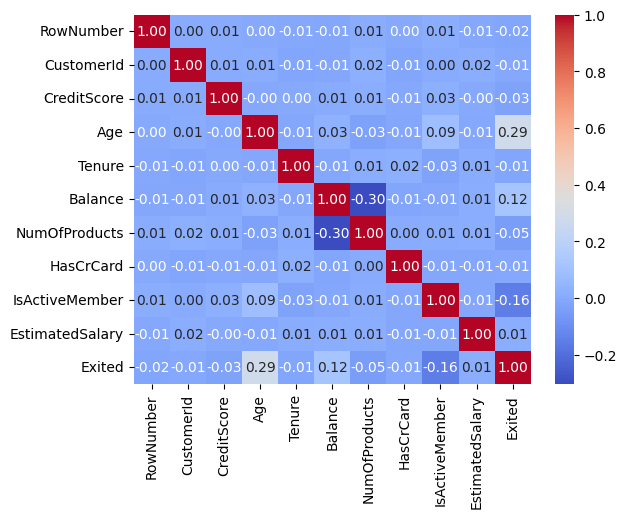

In [108]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")